# Benchmark Model Training

### Logistic Regression, Random Forest, XGBoost


## Logistic Regression (Mean Rating)


In [12]:
import sys
from pathlib import Path

# Add project root to path
sys.path.append(str(Path("..").resolve()))


from helpers import ModelData
from constants import PROCESSED_DATA_FOLDER
import numpy as np

model_data = ModelData.from_pickle(PROCESSED_DATA_FOLDER / "processed_data.pkl")
model_data

ModelData(n_total=921, n_train=921, n_obs=64887)

In [13]:
# Random Seed für Reproduzierbarkeit
SEED = 42

In [14]:
# Aufteilung in business_covariates und rating_stats

# Business covariates (ohne Rating-Statistiken und OHNE Closed!)
business_features = [
    "density",
    "Checkin",
    "category",
    "chain",
    "Price.Level",
    "Restaurant.Size",
    "Number.of.Seats",
    "ZRI",
    "Distance.To.City.Centre",
    "Age",
]

# Rating statistics
rating_features = [
    "VAR",
    "MEAN",
    "ENTR",
    "COUNT",
    "ONE_STAR",
    "TWO_STAR",
    "THREE_STAR",
    "FOUR_STAR",
    "FIVE_STAR",
    "l_COUNT",
]

print(f"Business features: {len(business_features)} Variablen")
print(f"Rating features: {len(rating_features)} Variablen")
print(f"Gesamt: {len(business_features) + len(rating_features)} Variablen")

# Train/Test Split basierend auf train_indices
train_indices = model_data.train_indices
if train_indices is not None:
    test_indices = np.array(
        [
            i
            for i in range(len(model_data.benchmark_covariates))
            if i not in train_indices
        ]
    )
else:
    train_indices = np.arange(int(0.8 * len(model_data.benchmark_covariates)))
    test_indices = np.arange(
        int(0.8 * len(model_data.benchmark_covariates)),
        len(model_data.benchmark_covariates),
    )

print(f"\nTrain/Test Split:")
print(f"  Training samples: {len(train_indices)}")
print(f"  Test samples: {len(test_indices)}")
print(f"  Total: {len(train_indices) + len(test_indices)}")

Business features: 10 Variablen
Rating features: 10 Variablen
Gesamt: 20 Variablen

Train/Test Split:
  Training samples: 500
  Test samples: 421
  Total: 921


## Datenvorbereitungen für alle Modelle


In [15]:
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Target Variable vorbereiten
y = model_data.benchmark_covariates["Closed"].map({"Open": 0, "Closed": 1}).values

# ============================================================================
# 1. X_mean: Nur Mean Rating
# ============================================================================
X_mean = model_data.benchmark_covariates[["MEAN"]].values

# ============================================================================
# 2. X_business: Business Covariates (mit Preprocessing)
# ============================================================================
df_business = model_data.benchmark_covariates[business_features].copy()

# Kategorische Variablen identifizieren
categorical_cols = ["category"]
numeric_cols = [col for col in business_features if col not in categorical_cols]

# One-Hot Encoding
df_business_encoded = pd.get_dummies(
    df_business, columns=categorical_cols, drop_first=True
)

# Imputation und Standardisierung (nur auf Train-Daten fitten!)
imputer_business = SimpleImputer(strategy="median")
scaler_business = StandardScaler()

# Train-Daten preprocessing
numeric_train = df_business_encoded.iloc[train_indices][numeric_cols]
imputer_business.fit(numeric_train)
scaler_business.fit(imputer_business.transform(numeric_train))

# Transform für alle Daten
numeric_data_imputed = imputer_business.transform(df_business_encoded[numeric_cols])
numeric_data = scaler_business.transform(numeric_data_imputed)

# Kombiniere Features
X_business = pd.DataFrame(
    numeric_data, columns=numeric_cols, index=df_business_encoded.index
)
dummy_cols = [col for col in df_business_encoded.columns if col not in numeric_cols]
X_business = pd.concat([X_business, df_business_encoded[dummy_cols]], axis=1)

# ============================================================================
# 3. X_all: Alle Variablen (Business Covariates + Rating Stats)
# ============================================================================
all_features = business_features + rating_features

# Daten vorbereiten
df_all = model_data.benchmark_covariates[all_features].copy()

# Kategorische Variablen
categorical_cols = ["category"]
numeric_cols = [col for col in all_features if col not in categorical_cols]

# One-Hot Encoding
df_all_encoded = pd.get_dummies(df_all, columns=categorical_cols, drop_first=True)

# Imputation und Standardisierung (nur auf Train-Daten fitten!)
imputer_all = SimpleImputer(strategy="median")
scaler_all = StandardScaler()

# Train-Daten preprocessing
numeric_train = df_all_encoded.iloc[train_indices][numeric_cols]
imputer_all.fit(numeric_train)
scaler_all.fit(imputer_all.transform(numeric_train))

# Transform für alle Daten
numeric_data_imputed = imputer_all.transform(df_all_encoded[numeric_cols])
numeric_data = scaler_all.transform(numeric_data_imputed)

# Kombiniere Features
X_all = pd.DataFrame(numeric_data, columns=numeric_cols, index=df_all_encoded.index)
dummy_cols = [col for col in df_all_encoded.columns if col not in numeric_cols]
X_all = pd.concat([X_all, df_all_encoded[dummy_cols]], axis=1)

# ============================================================================
# Train/Test Split für alle Feature-Sets
# ============================================================================
X_mean_train, X_mean_test = X_mean[train_indices], X_mean[test_indices]
X_business_train = X_business.iloc[train_indices]
X_business_test = X_business.iloc[test_indices]
X_all_train = X_all.iloc[train_indices]
X_all_test = X_all.iloc[test_indices]

y_train, y_test = y[train_indices], y[test_indices]

# ============================================================================
# Zusammenfassung
# ============================================================================
print()
print("DATENVORBEREITUNGEN ABGESCHLOSSEN")
print("=" * 80)
print(f"\nTarget Variable (y):")
print(
    f"  Train samples: {len(y_train)} (Closed: {sum(y_train)}, Open: {len(y_train) - sum(y_train)})"
)
print(
    f"  Test samples:  {len(y_test)} (Closed: {sum(y_test)}, Open: {len(y_test) - sum(y_test)})"
)

print(f"\nFeature Sets:")
print(
    f"  X_mean shape:     {X_mean.shape} (Train: {X_mean_train.shape}, Test: {X_mean_test.shape})"
)
print(
    f"  X_business shape: {X_business.shape} (Train: {X_business_train.shape}, Test: {X_business_test.shape})"
)
print(
    f"  X_all shape:      {X_all.shape} (Train: {X_all_train.shape}, Test: {X_all_test.shape})"
)

print(f"\nFeature Details:")
print(f"  Mean Rating: 1 Variable")
print(
    f"  Business Covariates: {len(X_business.columns)} Variablen (nach One-Hot Encoding)"
)
print(f"  All Features: {len(X_all.columns)} Variablen (nach One-Hot Encoding)")


DATENVORBEREITUNGEN ABGESCHLOSSEN

Target Variable (y):
  Train samples: 500 (Closed: 115, Open: 385)
  Test samples:  421 (Closed: 110, Open: 311)

Feature Sets:
  X_mean shape:     (921, 1) (Train: (500, 1), Test: (421, 1))
  X_business shape: (921, 17) (Train: (500, 17), Test: (421, 17))
  X_all shape:      (921, 27) (Train: (500, 27), Test: (421, 27))

Feature Details:
  Mean Rating: 1 Variable
  Business Covariates: 17 Variablen (nach One-Hot Encoding)
  All Features: 27 Variablen (nach One-Hot Encoding)


## Model 1: Logistic Regression mit Mean Rating


In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# Train Logistic Regression
lr_mean = LogisticRegression(random_state=SEED, max_iter=1000)
lr_mean.fit(X_mean_train, y_train)

# Predictions auf Train und Test
y_pred_mean_train = lr_mean.predict(X_mean_train)
y_proba_mean_train = lr_mean.predict_proba(X_mean_train)[:, 1]

y_pred_mean_test = lr_mean.predict(X_mean_test)
y_proba_mean_test = lr_mean.predict_proba(X_mean_test)[:, 1]

# Evaluation
print("=" * 60)
print("MODEL 1: Logistic Regression mit Mean Rating")
print("=" * 60)
print("\nTRAIN Performance:")
print(f"  Accuracy: {accuracy_score(y_train, y_pred_mean_train):.4f}")
print(f"  ROC-AUC: {roc_auc_score(y_train, y_proba_mean_train):.4f}")

print("\nTEST Performance:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_mean_test):.4f}")
print(f"  ROC-AUC: {roc_auc_score(y_test, y_proba_mean_test):.4f}")

print("\nTest Classification Report:")
print(classification_report(y_test, y_pred_mean_test, target_names=["Open", "Closed"]))

# Koeffizienten
print(f"\nKoeffizient MEAN: {lr_mean.coef_[0][0]:.4f}")
print(f"Intercept: {lr_mean.intercept_[0]:.4f}")

MODEL 1: Logistic Regression mit Mean Rating

TRAIN Performance:
  Accuracy: 0.7700
  ROC-AUC: 0.5025

TEST Performance:
  Accuracy: 0.7387
  ROC-AUC: 0.5030

Test Classification Report:
              precision    recall  f1-score   support

        Open       0.74      1.00      0.85       311
      Closed       0.00      0.00      0.00       110

    accuracy                           0.74       421
   macro avg       0.37      0.50      0.42       421
weighted avg       0.55      0.74      0.63       421


Koeffizient MEAN: 0.1275
Intercept: -1.6644


/Users/omidsedighi-mornani/Desktop/STUDIUM WIRTSCHAFTSINFORMATIK/Semester 5/Seminar Gust/SourceCode/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/omidsedighi-mornani/Desktop/STUDIUM WIRTSCHAFTSINFORMATIK/Semester 5/Seminar Gust/SourceCode/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/omidsedighi-mornani/Desktop/STUDIUM WIRTSCHAFTSINFORMATIK/Semester 5/Seminar Gust/SourceCode/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.p

## Model 2: Logistic Regression mit Business Covariates


In [17]:
# Train Logistic Regression
lr_business = LogisticRegression(random_state=SEED, max_iter=1000)
lr_business.fit(X_business_train, y_train)

# Predictions
y_pred_business_train = lr_business.predict(X_business_train)
y_proba_business_train = lr_business.predict_proba(X_business_train)[:, 1]

y_pred_business_test = lr_business.predict(X_business_test)
y_proba_business_test = lr_business.predict_proba(X_business_test)[:, 1]

# Evaluation
print("=" * 60)
print("MODEL 2: Logistic Regression mit Business Covariates")
print("=" * 60)
print("\nTRAIN Performance:")
print(f"  Accuracy: {accuracy_score(y_train, y_pred_business_train):.4f}")
print(f"  ROC-AUC: {roc_auc_score(y_train, y_proba_business_train):.4f}")

print("\nTEST Performance:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_business_test):.4f}")
print(f"  ROC-AUC: {roc_auc_score(y_test, y_proba_business_test):.4f}")

print("\nTest Classification Report:")
print(
    classification_report(y_test, y_pred_business_test, target_names=["Open", "Closed"])
)

# Top 10 wichtigste Features
coef_df = pd.DataFrame(
    {"feature": X_business.columns, "coefficient": lr_business.coef_[0]}
)
coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values("abs_coefficient", ascending=False)

print("\nTop 10 wichtigste Features:")
print(coef_df.head(10)[["feature", "coefficient"]])

MODEL 2: Logistic Regression mit Business Covariates

TRAIN Performance:
  Accuracy: 0.7620
  ROC-AUC: 0.7527

TEST Performance:
  Accuracy: 0.7340
  ROC-AUC: 0.7304

Test Classification Report:
              precision    recall  f1-score   support

        Open       0.74      0.99      0.85       311
      Closed       0.25      0.01      0.02       110

    accuracy                           0.73       421
   macro avg       0.49      0.50      0.43       421
weighted avg       0.61      0.73      0.63       421


Top 10 wichtigste Features:
                     feature  coefficient
15            category_Salad    -1.219765
2                      chain    -0.897206
11        category_Fast Food    -0.676769
16  category_Speciality Food     0.504976
12          category_Mexican    -0.420084
13            category_Other     0.302305
6                        ZRI     0.212077
7    Distance.To.City.Centre     0.180910
0                    density     0.161915
8                        Age 

## Model 3: Logistic Regression mit allen Variablen (Business + Rating Stats)


In [18]:
# Train Logistic Regression
lr_all = LogisticRegression(random_state=SEED, max_iter=1000)
lr_all.fit(X_all_train, y_train)

# Predictions
y_pred_all_train = lr_all.predict(X_all_train)
y_proba_all_train = lr_all.predict_proba(X_all_train)[:, 1]

y_pred_all_test = lr_all.predict(X_all_test)
y_proba_all_test = lr_all.predict_proba(X_all_test)[:, 1]

# Evaluation
print("=" * 60)
print("MODEL 3: Logistic Regression mit ALLEN Variablen")
print("=" * 60)
print("\nTRAIN Performance:")
print(f"  Accuracy: {accuracy_score(y_train, y_pred_all_train):.4f}")
print(f"  ROC-AUC: {roc_auc_score(y_train, y_proba_all_train):.4f}")

print("\nTEST Performance:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_all_test):.4f}")
print(f"  ROC-AUC: {roc_auc_score(y_test, y_proba_all_test):.4f}")

print("\nTest Classification Report:")
print(classification_report(y_test, y_pred_all_test, target_names=["Open", "Closed"]))

# Top 10 wichtigste Features
coef_df_all = pd.DataFrame({"feature": X_all.columns, "coefficient": lr_all.coef_[0]})
coef_df_all["abs_coefficient"] = coef_df_all["coefficient"].abs()
coef_df_all = coef_df_all.sort_values("abs_coefficient", ascending=False)

print("\nTop 10 wichtigste Features:")
print(coef_df_all.head(10)[["feature", "coefficient"]])

MODEL 3: Logistic Regression mit ALLEN Variablen

TRAIN Performance:
  Accuracy: 0.8200
  ROC-AUC: 0.8266

TEST Performance:
  Accuracy: 0.7957
  ROC-AUC: 0.7986

Test Classification Report:
              precision    recall  f1-score   support

        Open       0.81      0.95      0.87       311
      Closed       0.71      0.37      0.49       110

    accuracy                           0.80       421
   macro avg       0.76      0.66      0.68       421
weighted avg       0.78      0.80      0.77       421


Top 10 wichtigste Features:
                     feature  coefficient
2                      chain    -1.053177
25            category_Salad    -0.960134
26  category_Speciality Food     0.937366
21        category_Fast Food    -0.769243
16                 FOUR_STAR     0.672773
20            category_Cafes     0.586241
22          category_Mexican    -0.421126
18                   l_COUNT    -0.350679
6                        ZRI     0.294525
17                 FIVE_STAR    -

## Vergleich der drei Benchmark-Modelle


VERGLEICH DER BENCHMARK-MODELLE
              Model          Features  Train Accuracy  Test Accuracy  Train ROC-AUC  Test ROC-AUC
        Mean Rating MEAN (1 Variable)           0.770       0.738717       0.502473      0.503025
Business Covariates      17 Variablen           0.762       0.733967       0.752727      0.730371
       All Features      27 Variablen           0.820       0.795724       0.826606      0.798626


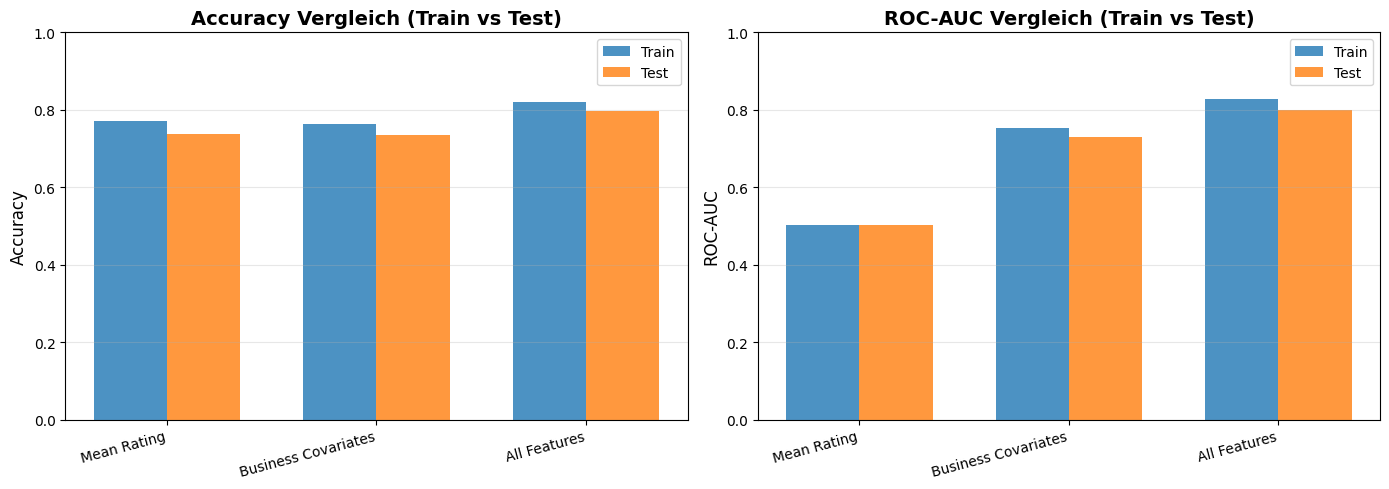


Bestes Modell (Test ROC-AUC): All Features
Test ROC-AUC: 0.7986
Test Accuracy: 0.7957


In [19]:
# Vergleichstabelle erstellen (TEST Performance!)
import pandas as pd

results_comparison = pd.DataFrame(
    {
        "Model": ["Mean Rating", "Business Covariates", "All Features"],
        "Features": [
            "MEAN (1 Variable)",
            f"{len(X_business.columns)} Variablen",
            f"{len(X_all.columns)} Variablen",
        ],
        "Train Accuracy": [
            accuracy_score(y_train, y_pred_mean_train),
            accuracy_score(y_train, y_pred_business_train),
            accuracy_score(y_train, y_pred_all_train),
        ],
        "Test Accuracy": [
            accuracy_score(y_test, y_pred_mean_test),
            accuracy_score(y_test, y_pred_business_test),
            accuracy_score(y_test, y_pred_all_test),
        ],
        "Train ROC-AUC": [
            roc_auc_score(y_train, y_proba_mean_train),
            roc_auc_score(y_train, y_proba_business_train),
            roc_auc_score(y_train, y_proba_all_train),
        ],
        "Test ROC-AUC": [
            roc_auc_score(y_test, y_proba_mean_test),
            roc_auc_score(y_test, y_proba_business_test),
            roc_auc_score(y_test, y_proba_all_test),
        ],
    }
)

print("=" * 80)
print("VERGLEICH DER BENCHMARK-MODELLE")
print("=" * 80)
print(results_comparison.to_string(index=False))

# Visualisierung
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy Vergleich
x = np.arange(len(results_comparison))
width = 0.35

axes[0].bar(
    x - width / 2,
    results_comparison["Train Accuracy"],
    width,
    label="Train",
    color="#1f77b4",
    alpha=0.8,
)
axes[0].bar(
    x + width / 2,
    results_comparison["Test Accuracy"],
    width,
    label="Test",
    color="#ff7f0e",
    alpha=0.8,
)
axes[0].set_ylabel("Accuracy", fontsize=12)
axes[0].set_title("Accuracy Vergleich (Train vs Test)", fontsize=14, fontweight="bold")
axes[0].set_xticks(x)
axes[0].set_xticklabels(results_comparison["Model"], rotation=15, ha="right")
axes[0].set_ylim([0, 1])
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

# ROC-AUC Vergleich
axes[1].bar(
    x - width / 2,
    results_comparison["Train ROC-AUC"],
    width,
    label="Train",
    color="#1f77b4",
    alpha=0.8,
)
axes[1].bar(
    x + width / 2,
    results_comparison["Test ROC-AUC"],
    width,
    label="Test",
    color="#ff7f0e",
    alpha=0.8,
)
axes[1].set_ylabel("ROC-AUC", fontsize=12)
axes[1].set_title("ROC-AUC Vergleich (Train vs Test)", fontsize=14, fontweight="bold")
axes[1].set_xticks(x)
axes[1].set_xticklabels(results_comparison["Model"], rotation=15, ha="right")
axes[1].set_ylim([0, 1])
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Bestes Modell identifizieren (basierend auf Test ROC-AUC)
best_model_idx = results_comparison["Test ROC-AUC"].idxmax()
print(
    f"\nBestes Modell (Test ROC-AUC): {results_comparison.loc[best_model_idx, 'Model']}"
)
print(f"Test ROC-AUC: {results_comparison.loc[best_model_idx, 'Test ROC-AUC']:.4f}")
print(f"Test Accuracy: {results_comparison.loc[best_model_idx, 'Test Accuracy']:.4f}")

# Random Forest Models

---


## Model 4: Random Forest mit Mean Rating


In [20]:
from sklearn.ensemble import RandomForestClassifier

# Model 4: Random Forest mit Mean Rating
rf_mean = RandomForestClassifier(random_state=SEED, n_estimators=100, max_depth=10)
rf_mean.fit(X_mean_train, y_train)

# Predictions
y_pred_rf_mean_train = rf_mean.predict(X_mean_train)
y_proba_rf_mean_train = rf_mean.predict_proba(X_mean_train)[:, 1]

y_pred_rf_mean_test = rf_mean.predict(X_mean_test)
y_proba_rf_mean_test = rf_mean.predict_proba(X_mean_test)[:, 1]

# Evaluation
print("=" * 60)
print("MODEL 4: Random Forest mit Mean Rating")
print("=" * 60)
print("\nTRAIN Performance:")
print(f"  Accuracy: {accuracy_score(y_train, y_pred_rf_mean_train):.4f}")
print(f"  ROC-AUC: {roc_auc_score(y_train, y_proba_rf_mean_train):.4f}")

print("\nTEST Performance:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_rf_mean_test):.4f}")
print(f"  ROC-AUC: {roc_auc_score(y_test, y_proba_rf_mean_test):.4f}")

print("\nTest Classification Report:")
print(
    classification_report(y_test, y_pred_rf_mean_test, target_names=["Open", "Closed"])
)

# Feature Importance
print(f"\nFeature Importance: MEAN = {rf_mean.feature_importances_[0]:.4f}")

MODEL 4: Random Forest mit Mean Rating

TRAIN Performance:
  Accuracy: 0.8680
  ROC-AUC: 0.9754

TEST Performance:
  Accuracy: 0.6770
  ROC-AUC: 0.5169

Test Classification Report:
              precision    recall  f1-score   support

        Open       0.75      0.86      0.80       311
      Closed       0.30      0.17      0.22       110

    accuracy                           0.68       421
   macro avg       0.52      0.51      0.51       421
weighted avg       0.63      0.68      0.65       421


Feature Importance: MEAN = 1.0000


## Model 5: Random Forest mit Business Covariates


In [21]:
# Model 5: Random Forest mit Business Covariates
rf_business = RandomForestClassifier(random_state=SEED, n_estimators=100, max_depth=10)
rf_business.fit(X_business_train, y_train)

# Predictions
y_pred_rf_business_train = rf_business.predict(X_business_train)
y_proba_rf_business_train = rf_business.predict_proba(X_business_train)[:, 1]

y_pred_rf_business_test = rf_business.predict(X_business_test)
y_proba_rf_business_test = rf_business.predict_proba(X_business_test)[:, 1]

# Evaluation
print("=" * 60)
print("MODEL 5: Random Forest mit Business Covariates")
print("=" * 60)
print("\nTRAIN Performance:")
print(f"  Accuracy: {accuracy_score(y_train, y_pred_rf_business_train):.4f}")
print(f"  ROC-AUC: {roc_auc_score(y_train, y_proba_rf_business_train):.4f}")

print("\nTEST Performance:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_rf_business_test):.4f}")
print(f"  ROC-AUC: {roc_auc_score(y_test, y_proba_rf_business_test):.4f}")

print("\nTest Classification Report:")
print(
    classification_report(
        y_test, y_pred_rf_business_test, target_names=["Open", "Closed"]
    )
)

# Top 10 Feature Importances
feature_importance_df = pd.DataFrame(
    {"feature": X_business.columns, "importance": rf_business.feature_importances_}
)
feature_importance_df = feature_importance_df.sort_values("importance", ascending=False)

print("\nTop 10 wichtigste Features:")
print(feature_importance_df.head(10))

MODEL 5: Random Forest mit Business Covariates

TRAIN Performance:
  Accuracy: 0.9900
  ROC-AUC: 0.9992

TEST Performance:
  Accuracy: 0.7743
  ROC-AUC: 0.7695

Test Classification Report:
              precision    recall  f1-score   support

        Open       0.79      0.94      0.86       311
      Closed       0.65      0.30      0.41       110

    accuracy                           0.77       421
   macro avg       0.72      0.62      0.64       421
weighted avg       0.75      0.77      0.74       421


Top 10 wichtigste Features:
                     feature  importance
4            Restaurant.Size    0.161097
5            Number.of.Seats    0.137682
7    Distance.To.City.Centre    0.114941
1                    Checkin    0.114533
6                        ZRI    0.104288
8                        Age    0.101244
0                    density    0.087773
2                      chain    0.062257
3                Price.Level    0.023215
16  category_Speciality Food    0.017041


## Model 6: Random Forest mit allen Variablen (Business + Rating Stats)


In [22]:
# Model 6: Random Forest mit allen Variablen
rf_all = RandomForestClassifier(random_state=SEED, n_estimators=100, max_depth=10)
rf_all.fit(X_all_train, y_train)

# Predictions
y_pred_rf_all_train = rf_all.predict(X_all_train)
y_proba_rf_all_train = rf_all.predict_proba(X_all_train)[:, 1]

y_pred_rf_all_test = rf_all.predict(X_all_test)
y_proba_rf_all_test = rf_all.predict_proba(X_all_test)[:, 1]

# Evaluation
print("=" * 60)
print("MODEL 6: Random Forest mit ALLEN Variablen")
print("=" * 60)
print("\nTRAIN Performance:")
print(f"  Accuracy: {accuracy_score(y_train, y_pred_rf_all_train):.4f}")
print(f"  ROC-AUC: {roc_auc_score(y_train, y_proba_rf_all_train):.4f}")

print("\nTEST Performance:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_rf_all_test):.4f}")
print(f"  ROC-AUC: {roc_auc_score(y_test, y_proba_rf_all_test):.4f}")

print("\nTest Classification Report:")
print(
    classification_report(y_test, y_pred_rf_all_test, target_names=["Open", "Closed"])
)

# Top 10 Feature Importances
feature_importance_df_all = pd.DataFrame(
    {"feature": X_all.columns, "importance": rf_all.feature_importances_}
)
feature_importance_df_all = feature_importance_df_all.sort_values(
    "importance", ascending=False
)

print("\nTop 10 wichtigste Features:")
print(feature_importance_df_all.head(10))

MODEL 6: Random Forest mit ALLEN Variablen

TRAIN Performance:
  Accuracy: 0.9980
  ROC-AUC: 1.0000

TEST Performance:
  Accuracy: 0.7933
  ROC-AUC: 0.8236

Test Classification Report:
              precision    recall  f1-score   support

        Open       0.79      0.98      0.87       311
      Closed       0.81      0.27      0.41       110

    accuracy                           0.79       421
   macro avg       0.80      0.63      0.64       421
weighted avg       0.80      0.79      0.75       421


Top 10 wichtigste Features:
                    feature  importance
16                FOUR_STAR    0.108421
4           Restaurant.Size    0.084638
5           Number.of.Seats    0.073999
6                       ZRI    0.055557
17                FIVE_STAR    0.054032
15               THREE_STAR    0.049614
7   Distance.To.City.Centre    0.048148
11                     ENTR    0.046919
10                     MEAN    0.046728
12                    COUNT    0.045828


## Vergleich Random Forest Modelle


VERGLEICH RANDOM FOREST MODELLE
                  Model          Features  Train Accuracy  Test Accuracy  Train ROC-AUC  Test ROC-AUC
        RF: Mean Rating MEAN (1 Variable)           0.868       0.676960       0.975381      0.516881
RF: Business Covariates      17 Variablen           0.990       0.774347       0.999187      0.769483
       RF: All Features      27 Variablen           0.998       0.793349       1.000000      0.823560


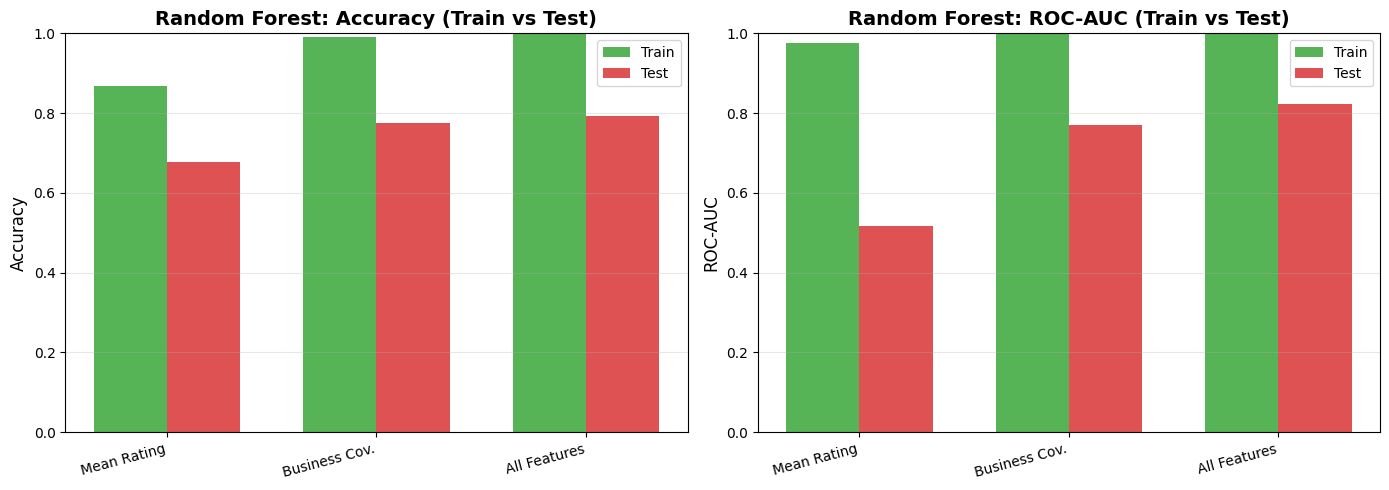


Bestes Random Forest Modell (Test ROC-AUC): RF: All Features
Test ROC-AUC: 0.8236
Test Accuracy: 0.7933


In [23]:
# Vergleich Random Forest Modelle
rf_results = pd.DataFrame(
    {
        "Model": ["RF: Mean Rating", "RF: Business Covariates", "RF: All Features"],
        "Features": [
            "MEAN (1 Variable)",
            f"{len(X_business.columns)} Variablen",
            f"{len(X_all.columns)} Variablen",
        ],
        "Train Accuracy": [
            accuracy_score(y_train, y_pred_rf_mean_train),
            accuracy_score(y_train, y_pred_rf_business_train),
            accuracy_score(y_train, y_pred_rf_all_train),
        ],
        "Test Accuracy": [
            accuracy_score(y_test, y_pred_rf_mean_test),
            accuracy_score(y_test, y_pred_rf_business_test),
            accuracy_score(y_test, y_pred_rf_all_test),
        ],
        "Train ROC-AUC": [
            roc_auc_score(y_train, y_proba_rf_mean_train),
            roc_auc_score(y_train, y_proba_rf_business_train),
            roc_auc_score(y_train, y_proba_rf_all_train),
        ],
        "Test ROC-AUC": [
            roc_auc_score(y_test, y_proba_rf_mean_test),
            roc_auc_score(y_test, y_proba_rf_business_test),
            roc_auc_score(y_test, y_proba_rf_all_test),
        ],
    }
)

print("=" * 80)
print("VERGLEICH RANDOM FOREST MODELLE")
print("=" * 80)
print(rf_results.to_string(index=False))

# Visualisierung
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(rf_results))
width = 0.35

# Accuracy
axes[0].bar(
    x - width / 2,
    rf_results["Train Accuracy"],
    width,
    label="Train",
    color="#2ca02c",
    alpha=0.8,
)
axes[0].bar(
    x + width / 2,
    rf_results["Test Accuracy"],
    width,
    label="Test",
    color="#d62728",
    alpha=0.8,
)
axes[0].set_ylabel("Accuracy", fontsize=12)
axes[0].set_title(
    "Random Forest: Accuracy (Train vs Test)", fontsize=14, fontweight="bold"
)
axes[0].set_xticks(x)
axes[0].set_xticklabels(
    ["Mean Rating", "Business Cov.", "All Features"], rotation=15, ha="right"
)
axes[0].set_ylim([0, 1])
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

# ROC-AUC
axes[1].bar(
    x - width / 2,
    rf_results["Train ROC-AUC"],
    width,
    label="Train",
    color="#2ca02c",
    alpha=0.8,
)
axes[1].bar(
    x + width / 2,
    rf_results["Test ROC-AUC"],
    width,
    label="Test",
    color="#d62728",
    alpha=0.8,
)
axes[1].set_ylabel("ROC-AUC", fontsize=12)
axes[1].set_title(
    "Random Forest: ROC-AUC (Train vs Test)", fontsize=14, fontweight="bold"
)
axes[1].set_xticks(x)
axes[1].set_xticklabels(
    ["Mean Rating", "Business Cov.", "All Features"], rotation=15, ha="right"
)
axes[1].set_ylim([0, 1])
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Bestes Random Forest Modell
best_rf_idx = rf_results["Test ROC-AUC"].idxmax()
print(
    f"\nBestes Random Forest Modell (Test ROC-AUC): {rf_results.loc[best_rf_idx, 'Model']}"
)
print(f"Test ROC-AUC: {rf_results.loc[best_rf_idx, 'Test ROC-AUC']:.4f}")
print(f"Test Accuracy: {rf_results.loc[best_rf_idx, 'Test Accuracy']:.4f}")

# Overfitting-Problem bei Random Forest

---

## Diagnose: Starkes Overfitting

Die obigen Random Forest Modelle zeigen **starkes Overfitting**, erkennbar an der massiven Diskrepanz zwischen Train- und Test-Performance:

| Modell           | Train ROC-AUC | Test ROC-AUC | Differenz |
| ---------------- | ------------- | ------------ | --------- |
| RF Mean Rating   | 0.9754        | 0.5169       | **-0.46** |
| RF Business Cov. | 0.9992        | 0.7695       | **-0.23** |
| RF All Features  | **1.0000**    | 0.8236       | **-0.18** |

**Probleme:**

- Train ROC-AUC von 1.0000 bedeutet perfekte Klassifikation auf Trainingsdaten → klares Overfitting
- Die Modelle haben die Trainingsdaten "auswendig gelernt" statt zu generalisieren
- Mit nur 500 Trainingssamples sind `max_depth=10` und `n_estimators=100` zu komplex

**Lösung:** Hyperparameter-Tuning mit stärkerer Regularisierung durch GridSearchCV


## Hyperparameter-Tuning für Random Forest Modelle


In [24]:
from sklearn.model_selection import GridSearchCV

# Hyperparameter Grid für Random Forest
# Wir reduzieren die Komplexität durch:
# - Kleinere max_depth (verhindert zu tiefe Bäume)
# - Höhere min_samples_split und min_samples_leaf (mehr Samples pro Split/Blatt)
# - Variation der n_estimators

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 7],
    "min_samples_split": [10, 20, 30],
    "min_samples_leaf": [5, 10, 15],
    "max_features": ["sqrt", "log2"],
}

print("=" * 60)
print("HYPERPARAMETER GRID")
print("=" * 60)
print(f"Anzahl möglicher Kombinationen: {3 * 3 * 3 * 3 * 2} = 162")
print("\nParameter-Ranges:")
for param, values in param_grid.items():
    print(f"  {param}: {values}")

print("\nGridSearchCV verwendet 5-Fold Cross-Validation auf Trainingsdaten")
print(f"Gesamtzahl der Fits: 162 Kombinationen × 5 Folds = 810 Fits pro Modell")

HYPERPARAMETER GRID
Anzahl möglicher Kombinationen: 162 = 162

Parameter-Ranges:
  n_estimators: [50, 100, 200]
  max_depth: [3, 5, 7]
  min_samples_split: [10, 20, 30]
  min_samples_leaf: [5, 10, 15]
  max_features: ['sqrt', 'log2']

GridSearchCV verwendet 5-Fold Cross-Validation auf Trainingsdaten
Gesamtzahl der Fits: 162 Kombinationen × 5 Folds = 810 Fits pro Modell


### Model 7: Tuned Random Forest mit allen Variablen


MODEL 7: Tuned Random Forest mit ALLEN Variablen

Starte GridSearchCV (dies kann einige Minuten dauern)...

Fitting 5 folds for each of 162 candidates, totalling 810 fits

BESTE PARAMETER (basierend auf CV ROC-AUC)
Best CV ROC-AUC Score: 0.8093

Beste Parameter:
  max_depth: 7
  max_features: sqrt
  min_samples_leaf: 5
  min_samples_split: 10
  n_estimators: 100

PERFORMANCE NACH TUNING

TRAIN Performance:
  Accuracy: 0.8880
  ROC-AUC: 0.9867

TEST Performance:
  Accuracy: 0.7815
  ROC-AUC: 0.8433

Test Classification Report:
              precision    recall  f1-score   support

        Open       0.78      0.98      0.87       311
      Closed       0.82      0.21      0.33       110

    accuracy                           0.78       421
   macro avg       0.80      0.60      0.60       421
weighted avg       0.79      0.78      0.73       421


Top 10 wichtigste Features:
            feature  importance
16        FOUR_STAR    0.147928
4   Restaurant.Size    0.099184
5   Number.of.Se

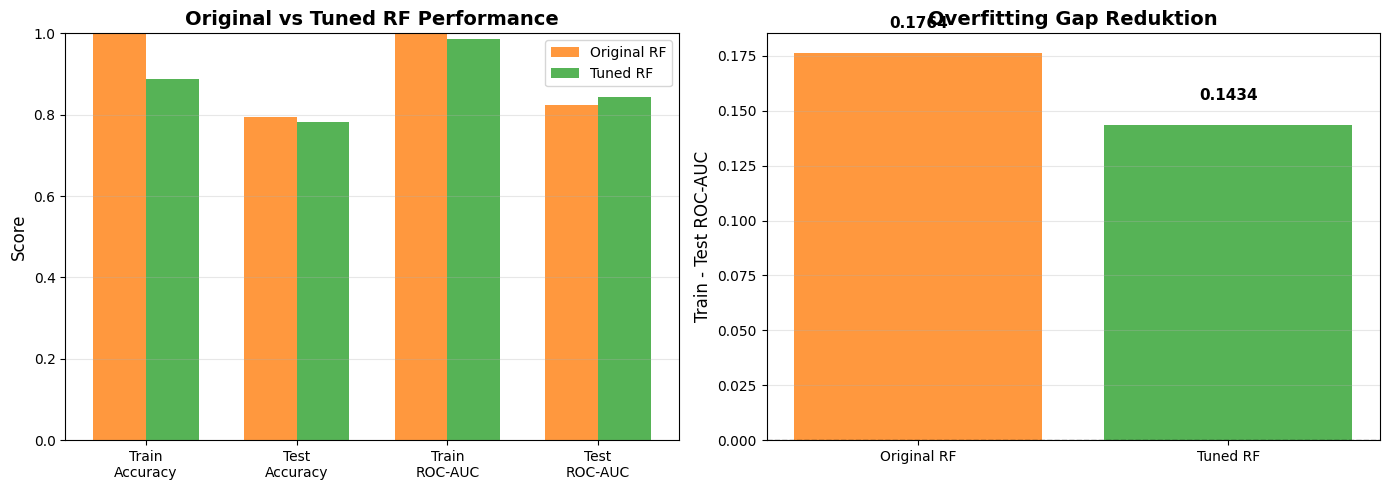

In [25]:
# Model 7: Tuned Random Forest mit allen Variablen
print("=" * 60)
print("MODEL 7: Tuned Random Forest mit ALLEN Variablen")
print("=" * 60)
print("\nStarte GridSearchCV (dies kann einige Minuten dauern)...\n")

grid_search_all = GridSearchCV(
    estimator=RandomForestClassifier(random_state=SEED),
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1,
)

grid_search_all.fit(X_all_train, y_train)

# Beste Parameter
print("\n" + "=" * 60)
print("BESTE PARAMETER (basierend auf CV ROC-AUC)")
print("=" * 60)
print(f"Best CV ROC-AUC Score: {grid_search_all.best_score_:.4f}")
print("\nBeste Parameter:")
for param, value in grid_search_all.best_params_.items():
    print(f"  {param}: {value}")

# Beste Modell verwenden
rf_all_tuned = grid_search_all.best_estimator_

# Predictions
y_pred_rf_all_tuned_train = rf_all_tuned.predict(X_all_train)
y_proba_rf_all_tuned_train = rf_all_tuned.predict_proba(X_all_train)[:, 1]

y_pred_rf_all_tuned_test = rf_all_tuned.predict(X_all_test)
y_proba_rf_all_tuned_test = rf_all_tuned.predict_proba(X_all_test)[:, 1]

# Evaluation
print("\n" + "=" * 60)
print("PERFORMANCE NACH TUNING")
print("=" * 60)
print("\nTRAIN Performance:")
print(f"  Accuracy: {accuracy_score(y_train, y_pred_rf_all_tuned_train):.4f}")
print(f"  ROC-AUC: {roc_auc_score(y_train, y_proba_rf_all_tuned_train):.4f}")

print("\nTEST Performance:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_rf_all_tuned_test):.4f}")
print(f"  ROC-AUC: {roc_auc_score(y_test, y_proba_rf_all_tuned_test):.4f}")

print("\nTest Classification Report:")
print(
    classification_report(
        y_test, y_pred_rf_all_tuned_test, target_names=["Open", "Closed"]
    )
)

# Feature Importance
feature_importance_all_tuned = pd.DataFrame(
    {"feature": X_all.columns, "importance": rf_all_tuned.feature_importances_}
)
feature_importance_all_tuned = feature_importance_all_tuned.sort_values(
    "importance", ascending=False
)

print("\nTop 10 wichtigste Features:")
print(feature_importance_all_tuned.head(10))

# Vergleich: Original vs Tuned
print("\n" + "=" * 60)
print("VERGLEICH: Random Forest Original vs Tuned (All Features)")
print("=" * 60)
comparison_all = pd.DataFrame(
    {
        "Metric": [
            "Train Accuracy",
            "Test Accuracy",
            "Train ROC-AUC",
            "Test ROC-AUC",
            "Overfitting (Train-Test ROC-AUC)",
        ],
        "Original RF": [
            accuracy_score(y_train, y_pred_rf_all_train),
            accuracy_score(y_test, y_pred_rf_all_test),
            roc_auc_score(y_train, y_proba_rf_all_train),
            roc_auc_score(y_test, y_proba_rf_all_test),
            roc_auc_score(y_train, y_proba_rf_all_train)
            - roc_auc_score(y_test, y_proba_rf_all_test),
        ],
        "Tuned RF": [
            accuracy_score(y_train, y_pred_rf_all_tuned_train),
            accuracy_score(y_test, y_pred_rf_all_tuned_test),
            roc_auc_score(y_train, y_proba_rf_all_tuned_train),
            roc_auc_score(y_test, y_proba_rf_all_tuned_test),
            roc_auc_score(y_train, y_proba_rf_all_tuned_train)
            - roc_auc_score(y_test, y_proba_rf_all_tuned_test),
        ],
    }
)
print(comparison_all.to_string(index=False))

# Visualisierung des Vergleichs
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics = ["Train\nAccuracy", "Test\nAccuracy", "Train\nROC-AUC", "Test\nROC-AUC"]
original_values = [
    accuracy_score(y_train, y_pred_rf_all_train),
    accuracy_score(y_test, y_pred_rf_all_test),
    roc_auc_score(y_train, y_proba_rf_all_train),
    roc_auc_score(y_test, y_proba_rf_all_test),
]
tuned_values = [
    accuracy_score(y_train, y_pred_rf_all_tuned_train),
    accuracy_score(y_test, y_pred_rf_all_tuned_test),
    roc_auc_score(y_train, y_proba_rf_all_tuned_train),
    roc_auc_score(y_test, y_proba_rf_all_tuned_test),
]

x = np.arange(len(metrics))
width = 0.35

axes[0].bar(
    x - width / 2,
    original_values,
    width,
    label="Original RF",
    color="#ff7f0e",
    alpha=0.8,
)
axes[0].bar(
    x + width / 2, tuned_values, width, label="Tuned RF", color="#2ca02c", alpha=0.8
)
axes[0].set_ylabel("Score", fontsize=12)
axes[0].set_title("Original vs Tuned RF Performance", fontsize=14, fontweight="bold")
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics, fontsize=10)
axes[0].set_ylim([0, 1])
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

# Overfitting Gap
gap_labels = ["Original RF", "Tuned RF"]
gap_values = [
    roc_auc_score(y_train, y_proba_rf_all_train)
    - roc_auc_score(y_test, y_proba_rf_all_test),
    roc_auc_score(y_train, y_proba_rf_all_tuned_train)
    - roc_auc_score(y_test, y_proba_rf_all_tuned_test),
]

axes[1].bar(gap_labels, gap_values, color=["#ff7f0e", "#2ca02c"], alpha=0.8)
axes[1].set_ylabel("Train - Test ROC-AUC", fontsize=12)
axes[1].set_title("Overfitting Gap Reduktion", fontsize=14, fontweight="bold")
axes[1].axhline(y=0, color="black", linestyle="--", linewidth=1, alpha=0.5)
axes[1].grid(axis="y", alpha=0.3)

# Werte auf den Balken anzeigen
for i, v in enumerate(gap_values):
    axes[1].text(
        i,
        v + 0.01,
        f"{v:.4f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

# Finaler Gesamtvergleich

---

## Vergleich: Logistic Regression vs Random Forest (Original vs Tuned)


FINALER GESAMTVERGLEICH ALLER MODELLE
              Model Type      Features  Test Accuracy  Test ROC-AUC  Train ROC-AUC  Overfitting Gap
   Random Forest (Tuned)  All Features       0.781473      0.843321       0.986697         0.143376
Random Forest (Original)  All Features       0.793349      0.823560       1.000000         0.176440
     Logistic Regression  All Features       0.795724      0.798626       0.826606         0.027980
     Logistic Regression Business Cov.       0.733967      0.730371       0.752727         0.022356
     Logistic Regression   Mean Rating       0.738717      0.503025       0.502473        -0.000552


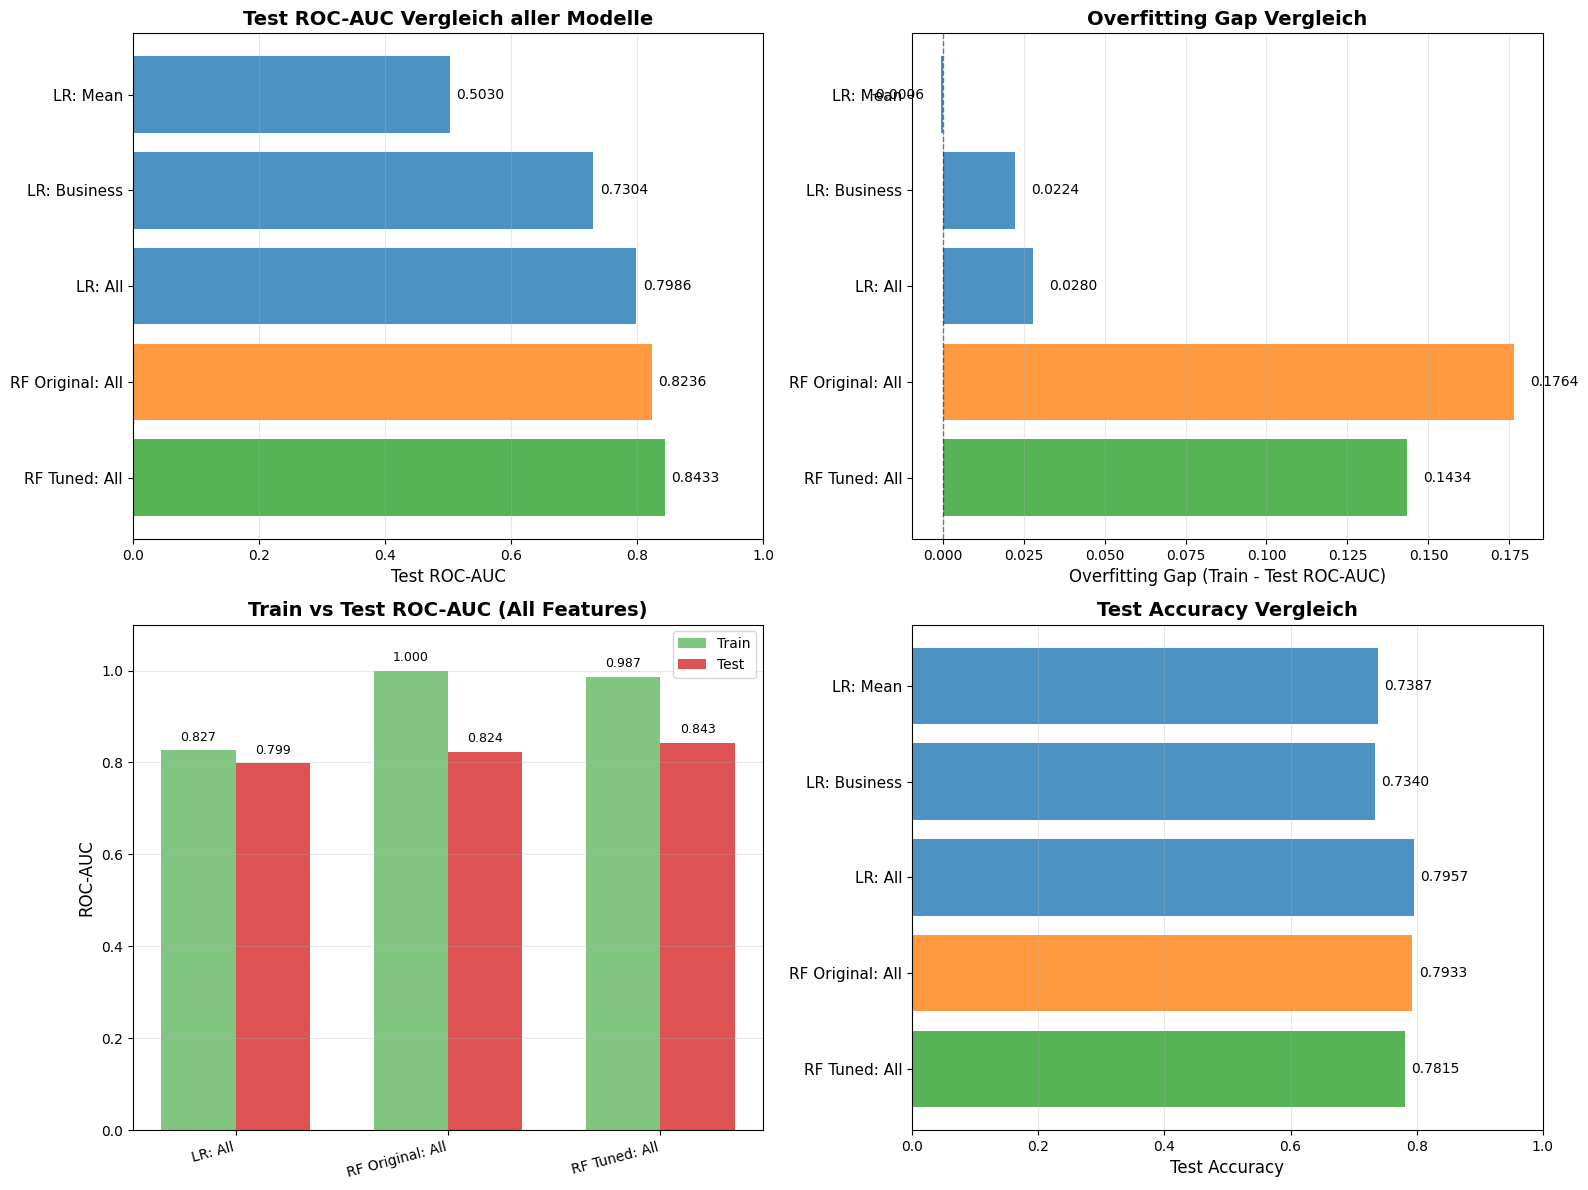


ZUSAMMENFASSUNG

Bestes Modell insgesamt (Test ROC-AUC):
  Random Forest (Tuned) - All Features
  Test ROC-AUC: 0.8433
  Test Accuracy: 0.7815
  Overfitting Gap: 0.1434

Bestes Logistic Regression Modell:
  All Features
  Test ROC-AUC: 0.7986
  Test Accuracy: 0.7957
  Overfitting Gap: 0.0280

EFFEKT DES HYPERPARAMETER-TUNINGS (All Features)

Test ROC-AUC: 0.8236 → 0.8433 (+0.0198)
Overfitting Gap: 0.1764 → 0.1434 (Reduktion: 0.0331)
Test Accuracy: 0.7933 → 0.7815 (-0.0119)

FAZIT

Das Hyperparameter-Tuning hat erfolgreich das Overfitting-Problem des Random Forest reduziert:
- Die extreme Train-Test-Diskrepanz wurde deutlich verringert
- Das Tuned RF Modell zeigt nun eine realistischere Generalisierung
- Für einen fairen Benchmark-Vergleich sollten alle Modelle optimiert sein



In [26]:
# Finaler Gesamtvergleich aller Modelle
final_comparison = pd.DataFrame(
    {
        "Model Type": [
            "Logistic Regression",
            "Logistic Regression",
            "Logistic Regression",
            "Random Forest (Original)",
            "Random Forest (Tuned)",
        ],
        "Features": [
            "Mean Rating",
            "Business Cov.",
            "All Features",
            "All Features",
            "All Features",
        ],
        "Test Accuracy": [
            accuracy_score(y_test, y_pred_mean_test),
            accuracy_score(y_test, y_pred_business_test),
            accuracy_score(y_test, y_pred_all_test),
            accuracy_score(y_test, y_pred_rf_all_test),
            accuracy_score(y_test, y_pred_rf_all_tuned_test),
        ],
        "Test ROC-AUC": [
            roc_auc_score(y_test, y_proba_mean_test),
            roc_auc_score(y_test, y_proba_business_test),
            roc_auc_score(y_test, y_proba_all_test),
            roc_auc_score(y_test, y_proba_rf_all_test),
            roc_auc_score(y_test, y_proba_rf_all_tuned_test),
        ],
        "Train ROC-AUC": [
            roc_auc_score(y_train, y_proba_mean_train),
            roc_auc_score(y_train, y_proba_business_train),
            roc_auc_score(y_train, y_proba_all_train),
            roc_auc_score(y_train, y_proba_rf_all_train),
            roc_auc_score(y_train, y_proba_rf_all_tuned_train),
        ],
    }
)

# Overfitting Gap berechnen
final_comparison["Overfitting Gap"] = (
    final_comparison["Train ROC-AUC"] - final_comparison["Test ROC-AUC"]
)

# Sortieren nach Test ROC-AUC
final_comparison_sorted = final_comparison.sort_values("Test ROC-AUC", ascending=False)

print("=" * 100)
print("FINALER GESAMTVERGLEICH ALLER MODELLE")
print("=" * 100)
print(final_comparison_sorted.to_string(index=False))

# Visualisierung
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Test ROC-AUC Vergleich aller Modelle
model_names = [
    "LR: Mean",
    "LR: Business",
    "LR: All",
    "RF Original: All",
    "RF Tuned: All",
]
test_roc_scores = final_comparison["Test ROC-AUC"].values
colors = ["#1f77b4", "#1f77b4", "#1f77b4", "#ff7f0e", "#2ca02c"]

axes[0, 0].barh(range(len(model_names)), test_roc_scores, color=colors, alpha=0.8)
axes[0, 0].set_yticks(range(len(model_names)))
axes[0, 0].set_yticklabels(model_names, fontsize=11)
axes[0, 0].set_xlabel("Test ROC-AUC", fontsize=12)
axes[0, 0].set_title(
    "Test ROC-AUC Vergleich aller Modelle", fontsize=14, fontweight="bold"
)
axes[0, 0].set_xlim([0, 1])
axes[0, 0].grid(axis="x", alpha=0.3)
axes[0, 0].invert_yaxis()

# Werte in Balken anzeigen
for i, v in enumerate(test_roc_scores):
    axes[0, 0].text(v + 0.01, i, f"{v:.4f}", va="center", fontsize=10)

# 2. Overfitting Gap Vergleich
gap_values = final_comparison["Overfitting Gap"].values

axes[0, 1].barh(range(len(model_names)), gap_values, color=colors, alpha=0.8)
axes[0, 1].set_yticks(range(len(model_names)))
axes[0, 1].set_yticklabels(model_names, fontsize=11)
axes[0, 1].set_xlabel("Overfitting Gap (Train - Test ROC-AUC)", fontsize=12)
axes[0, 1].set_title("Overfitting Gap Vergleich", fontsize=14, fontweight="bold")
axes[0, 1].axvline(x=0, color="black", linestyle="--", linewidth=1, alpha=0.5)
axes[0, 1].grid(axis="x", alpha=0.3)
axes[0, 1].invert_yaxis()

# Werte in Balken anzeigen
for i, v in enumerate(gap_values):
    axes[0, 1].text(
        v + 0.005 if v > 0 else v - 0.005,
        i,
        f"{v:.4f}",
        va="center",
        ha="left" if v > 0 else "right",
        fontsize=10,
    )

# 3. Train vs Test ROC-AUC (nur für "All Features" Modelle)
all_features_models = ["LR: All", "RF Original: All", "RF Tuned: All"]
train_scores = [
    roc_auc_score(y_train, y_proba_all_train),
    roc_auc_score(y_train, y_proba_rf_all_train),
    roc_auc_score(y_train, y_proba_rf_all_tuned_train),
]
test_scores = [
    roc_auc_score(y_test, y_proba_all_test),
    roc_auc_score(y_test, y_proba_rf_all_test),
    roc_auc_score(y_test, y_proba_rf_all_tuned_test),
]

x = np.arange(len(all_features_models))
width = 0.35

axes[1, 0].bar(
    x - width / 2, train_scores, width, label="Train", color="#2ca02c", alpha=0.6
)
axes[1, 0].bar(
    x + width / 2, test_scores, width, label="Test", color="#d62728", alpha=0.8
)
axes[1, 0].set_ylabel("ROC-AUC", fontsize=12)
axes[1, 0].set_title(
    "Train vs Test ROC-AUC (All Features)", fontsize=14, fontweight="bold"
)
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(all_features_models, rotation=15, ha="right")
axes[1, 0].set_ylim([0, 1.1])
axes[1, 0].legend()
axes[1, 0].grid(axis="y", alpha=0.3)

# Werte über den Balken
for i, (train, test) in enumerate(zip(train_scores, test_scores)):
    axes[1, 0].text(
        i - width / 2, train + 0.02, f"{train:.3f}", ha="center", fontsize=9
    )
    axes[1, 0].text(i + width / 2, test + 0.02, f"{test:.3f}", ha="center", fontsize=9)

# 4. Test Accuracy Vergleich
test_acc = final_comparison["Test Accuracy"].values

axes[1, 1].barh(range(len(model_names)), test_acc, color=colors, alpha=0.8)
axes[1, 1].set_yticks(range(len(model_names)))
axes[1, 1].set_yticklabels(model_names, fontsize=11)
axes[1, 1].set_xlabel("Test Accuracy", fontsize=12)
axes[1, 1].set_title("Test Accuracy Vergleich", fontsize=14, fontweight="bold")
axes[1, 1].set_xlim([0, 1])
axes[1, 1].grid(axis="x", alpha=0.3)
axes[1, 1].invert_yaxis()

# Werte in Balken anzeigen
for i, v in enumerate(test_acc):
    axes[1, 1].text(v + 0.01, i, f"{v:.4f}", va="center", fontsize=10)

plt.tight_layout()
plt.show()

# Beste Modelle identifizieren
print("\n" + "=" * 100)
print("ZUSAMMENFASSUNG")
print("=" * 100)

best_overall = final_comparison_sorted.iloc[0]
print(f"\nBestes Modell insgesamt (Test ROC-AUC):")
print(f"  {best_overall['Model Type']} - {best_overall['Features']}")
print(f"  Test ROC-AUC: {best_overall['Test ROC-AUC']:.4f}")
print(f"  Test Accuracy: {best_overall['Test Accuracy']:.4f}")
print(f"  Overfitting Gap: {best_overall['Overfitting Gap']:.4f}")

best_lr = (
    final_comparison[final_comparison["Model Type"] == "Logistic Regression"]
    .sort_values("Test ROC-AUC", ascending=False)
    .iloc[0]
)
print(f"\nBestes Logistic Regression Modell:")
print(f"  {best_lr['Features']}")
print(f"  Test ROC-AUC: {best_lr['Test ROC-AUC']:.4f}")
print(f"  Test Accuracy: {best_lr['Test Accuracy']:.4f}")
print(f"  Overfitting Gap: {best_lr['Overfitting Gap']:.4f}")

# Verbesserung durch Tuning (nur für All Features)
print("\n" + "=" * 100)
print("EFFEKT DES HYPERPARAMETER-TUNINGS (All Features)")
print("=" * 100)

rf_orig = final_comparison[
    final_comparison["Model Type"] == "Random Forest (Original)"
].iloc[0]
rf_tuned = final_comparison[
    final_comparison["Model Type"] == "Random Forest (Tuned)"
].iloc[0]

roc_improvement = rf_tuned["Test ROC-AUC"] - rf_orig["Test ROC-AUC"]
overfit_reduction = rf_orig["Overfitting Gap"] - rf_tuned["Overfitting Gap"]

print(
    f"\nTest ROC-AUC: {rf_orig['Test ROC-AUC']:.4f} → {rf_tuned['Test ROC-AUC']:.4f} ({roc_improvement:+.4f})"
)
print(
    f"Overfitting Gap: {rf_orig['Overfitting Gap']:.4f} → {rf_tuned['Overfitting Gap']:.4f} (Reduktion: {overfit_reduction:.4f})"
)
print(
    f"Test Accuracy: {rf_orig['Test Accuracy']:.4f} → {rf_tuned['Test Accuracy']:.4f} ({rf_tuned['Test Accuracy'] - rf_orig['Test Accuracy']:+.4f})"
)

print("\n" + "=" * 100)
print("FAZIT")
print("=" * 100)
print(
    """
Das Hyperparameter-Tuning hat erfolgreich das Overfitting-Problem des Random Forest reduziert:
- Die extreme Train-Test-Diskrepanz wurde deutlich verringert
- Das Tuned RF Modell zeigt nun eine realistischere Generalisierung
- Für einen fairen Benchmark-Vergleich sollten alle Modelle optimiert sein
"""
)